# Non-rigid safety: bounds and knot-count model selection

This advanced tutorial teaches two decisions: **when a motion bound is too
tight** and **when extra knots are not justified by the specimen**.

The same affine-corrected WS₂ pair is tested first with a deliberately tight
motion bound, then with a working bound. Every other solver setting is
identical. Compare the RGB images and metrics before applying one conservative
result.

Start with `../2d_nonrigid_ws2.ipynb` if knots are new to you.

Download the [raw WS2 data](https://drive.google.com/drive/folders/108vcQW2ycaZ1scKTWJK5jVCNfGZnxaiB?usp=sharing) and place the files in `tutorials/data/ws2/`.


## Import and configure


In [1]:
import os
from pathlib import Path

import quantem.widget as qw
from quantem.imaging import DriftCorrection

DATA = Path(os.environ.get("QUANTEM_DRIFT_WS2_DATA", "../data/ws2"))
FILES = (
    "0127_VWS2_9h_g_300kv_STEM_HAADF_5.20_Mx_Diffraction.emd",
    "0128_VWS2_9h_g_300kv_STEM_HAADF_5.20_Mx_Diffraction.emd",
)

KNOT_COUNTS = (1, 2, 3)
TIGHT_MAX_SHIFT = 1
WORKING_MAX_SHIFT = 2

# Shared settings keep max_image_shift as the only changed solver choice.
NONRIGID_OPTIONS = dict(
    optimizer="adam",
    num_refine_cycles=64,
    optimizer_steps=30,
    learning_rate=0.1,
    knot_smoothing_sigma=8.0,
    update_fraction=0.8,
    trend_order=1,
    loss="mse",
    early_stop_patience=8,
    min_iterations=4,
    verbose=True,
)

SUMMARY_COLUMNS = [
    "num_knots",
    "common_ncc",
    "yellow",
    "within_scanline_change_px",
]

# Interactive is the recommended default. False uses static/report rendering.
INTERACTIVE = True
VIEW_MODE = "interactive" if INTERACTIVE else "static"

qw.profile()


quantem.widget  0.0.1rc37
  install       published package
quantem.gpu     0.0.1rc6
  install       source override (differs from installed metadata)
quantem         0.1.9
torch           2.13.0  device=cuda (NVIDIA RTX PRO 6000)
GPUs            1 visible (CUDA_VISIBLE_DEVICES=0)
  GPU0           24.6 used / 102 GB  (77 free)
  torch pool    0.0 live / 0.0 reserved GB
python          3.14.6


## Load the orthogonal EMD pair

`from_emd()` reads scan rotation and calibration from microscope metadata.
Set `QUANTEM_DRIFT_WS2_DATA` to use another folder with these files.


In [2]:
drift = DriftCorrection.from_emd(
    DATA / FILES[0],
    DATA / FILES[1],
    verbose=False,
)


## Establish the affine starting point

Always solve and inspect affine registration first. Non-rigid correction
should polish a good affine result, not rescue a bad one.


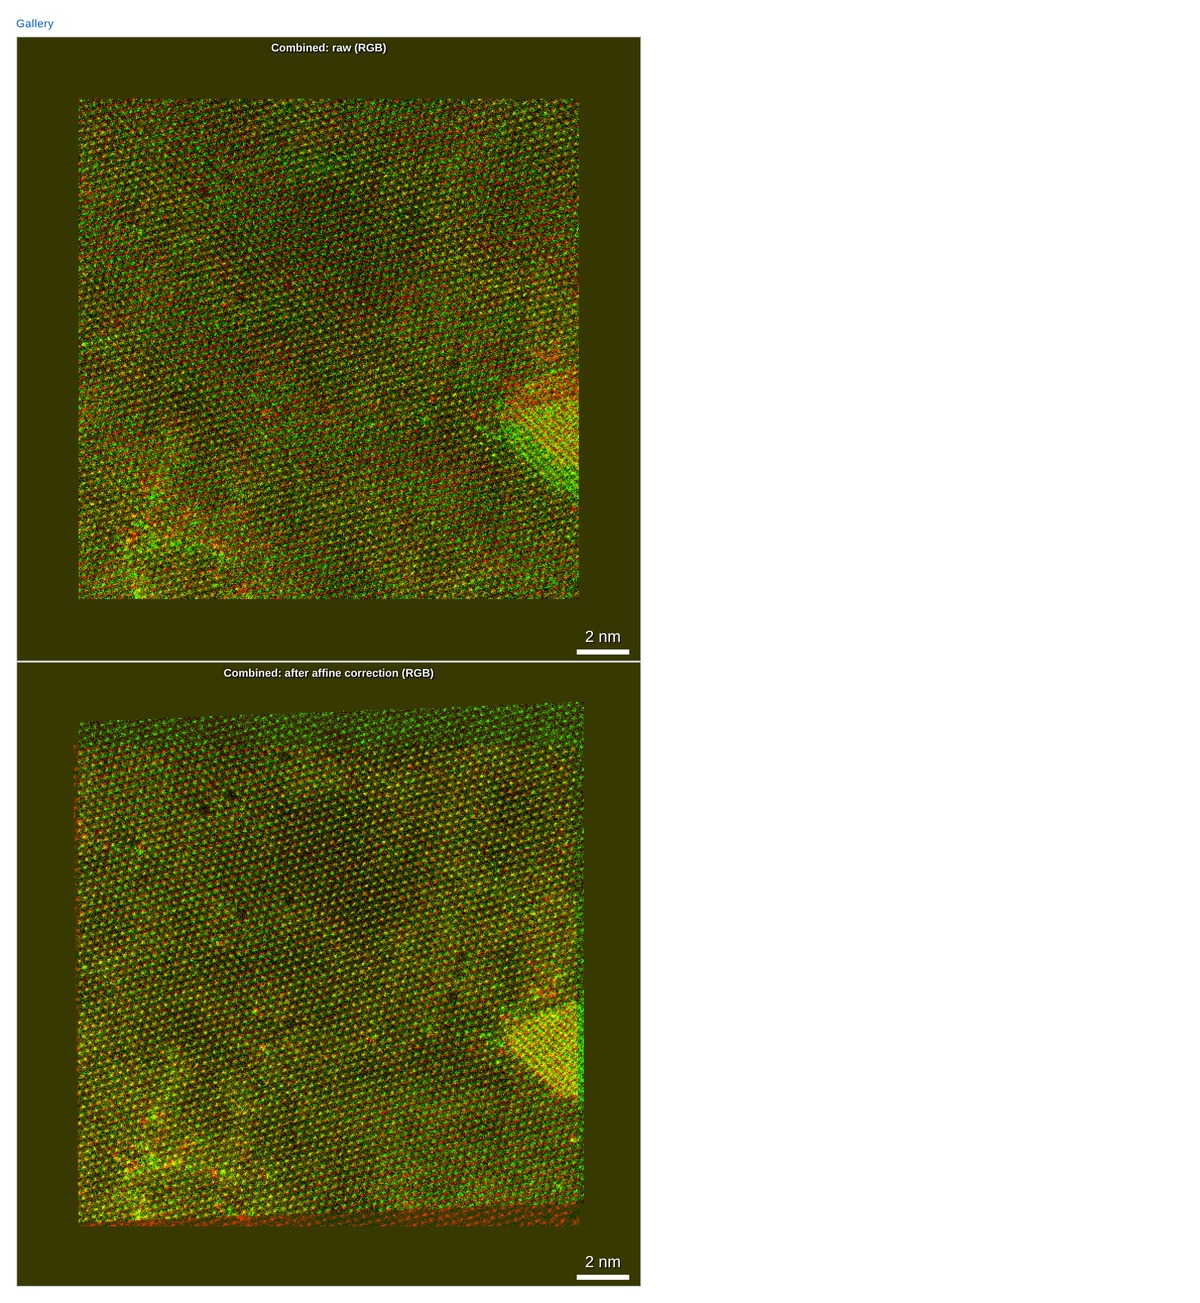

In [3]:
drift.correct_affine(
    show_combined=False,
    show_scans=False,
    verbose=False,
)

drift.plot_combined(
    stage=("initial", "affine"),
    interactive=INTERACTIVE,
    width=620,
)


## What the safety metric means

The **fast-scan direction** is the direction the beam sweeps along each
scanline. With two or three knots, neighboring control points may request
different shifts and bend the correction within that line.

`within_scanline_change_px` is the typical pixel difference between neighboring
control points. It is not image noise. One knot has no neighbor, so it is zero.

A larger value is not automatically wrong, but it needs visible, physical
support in the RGB comparison.


## Deliberately tight motion bound

This 1 px bound is a negative control. If every candidate remains worse than
the affine checkpoint, the bound is blocking needed motion. Do not select a
model from a failed comparison.


Diagnosing non-rigid knot counts:   0%|          | 0/3 [00:00<?, ?candidate/s]

Diagnosing non-rigid knot counts:  33%|███▎      | 1/3 [00:09<00:18,  9.18s/candidate]

Diagnosing non-rigid knot counts:  67%|██████▋   | 2/3 [00:12<00:06,  6.01s/candidate]

Diagnosing non-rigid knot counts: 100%|██████████| 3/3 [00:16<00:00,  4.67s/candidate]

Diagnosing non-rigid knot counts: 100%|██████████| 3/3 [00:16<00:00,  5.35s/candidate]

,num_knots,common_ncc,yellow,within_scanline_change_px
0,1,0.181335,0.494021,0.00000
1,2,0.141217,0.484937,2.97787
2,3,0.155568,0.487300,1.89758


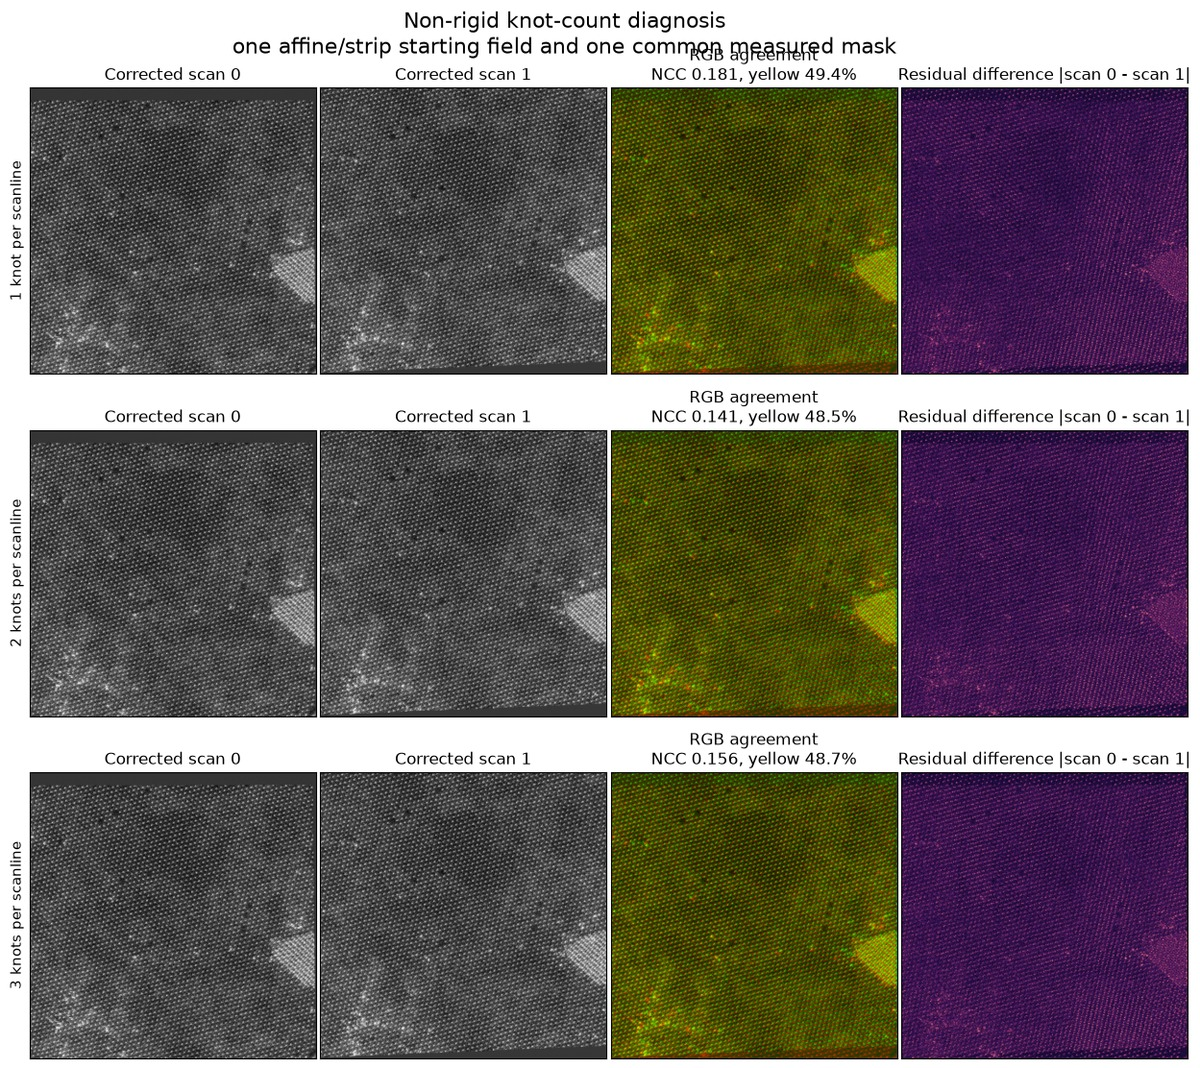

In [4]:
tight_figure, tight_metrics = drift.diagnose_nonrigid(
    num_knots=KNOT_COUNTS,
    max_image_shift=TIGHT_MAX_SHIFT,
    **NONRIGID_OPTIONS,
)
tight_summary = tight_metrics.rename(
    columns={"fast_roughness_px": "within_scanline_change_px"}
)
tight_summary[SUMMARY_COLUMNS]


## Working motion bound

The 2 px bound permits the one-knot correction to improve on affine. Two and
three knots may score still higher, but that alone does not make either model
preferable.


Diagnosing non-rigid knot counts:   0%|          | 0/3 [00:00<?, ?candidate/s]

Diagnosing non-rigid knot counts:  33%|███▎      | 1/3 [00:06<00:13,  6.67s/candidate]

Diagnosing non-rigid knot counts:  67%|██████▋   | 2/3 [00:15<00:07,  7.70s/candidate]

Diagnosing non-rigid knot counts: 100%|██████████| 3/3 [00:22<00:00,  7.57s/candidate]

Diagnosing non-rigid knot counts: 100%|██████████| 3/3 [00:22<00:00,  7.50s/candidate]

,num_knots,common_ncc,yellow,within_scanline_change_px
0,1,0.368211,0.548354,0.000000
1,2,0.426146,0.560445,4.414690
2,3,0.430703,0.562025,3.056267


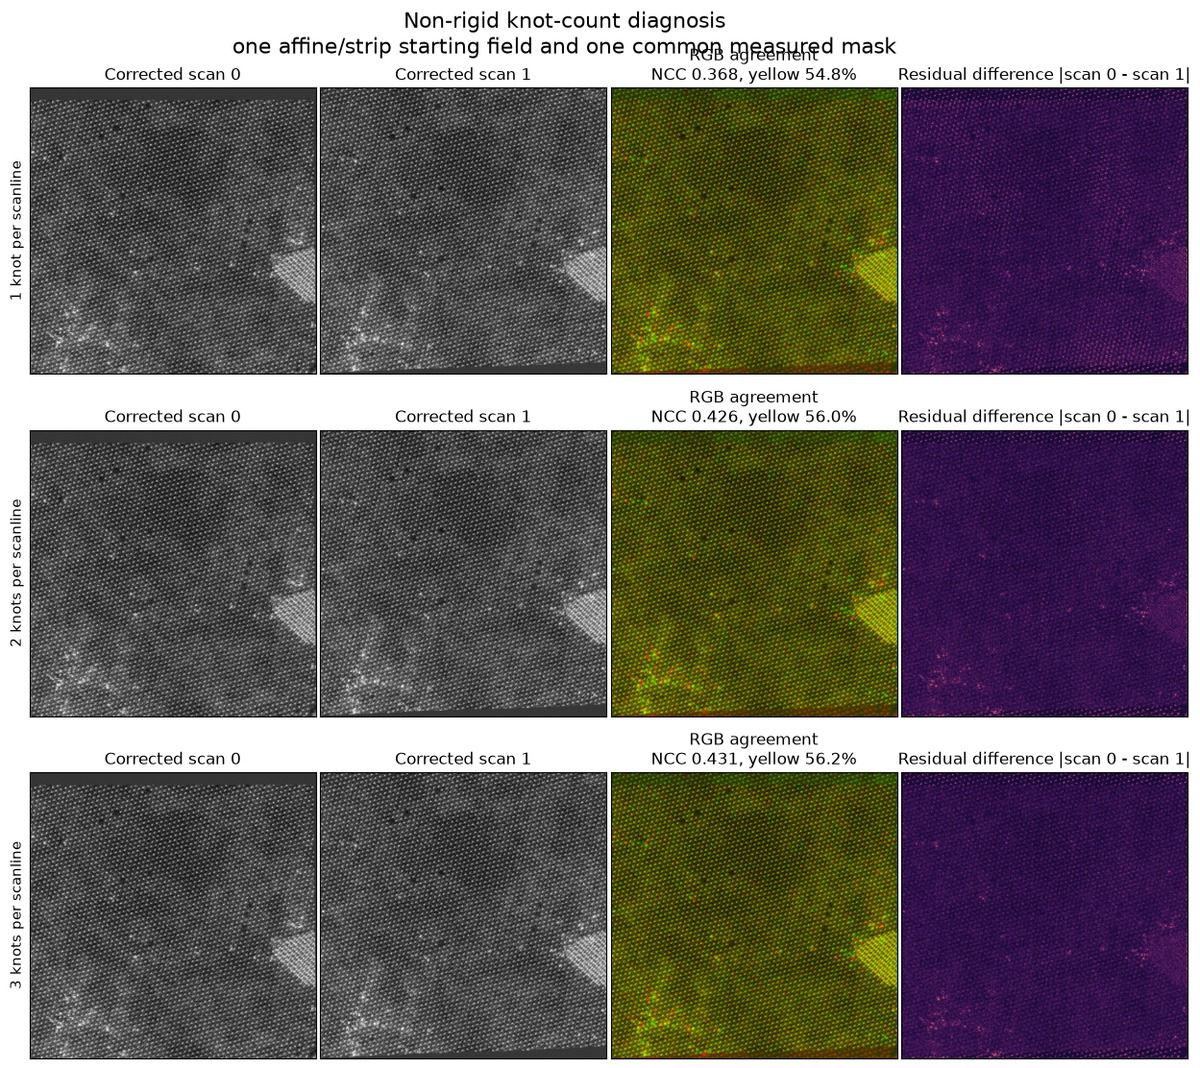

In [5]:
working_figure, working_metrics = drift.diagnose_nonrigid(
    num_knots=KNOT_COUNTS,
    max_image_shift=WORKING_MAX_SHIFT,
    **NONRIGID_OPTIONS,
)
working_summary = working_metrics.rename(
    columns={"fast_roughness_px": "within_scanline_change_px"}
)
working_summary[SUMMARY_COLUMNS]


## Decide before applying

Prefer the smallest model supported by the images. Reject a candidate when:

- NCC rises but the RGB panel gains periodic red/green fringes;
- neighboring knots move by several pixels without a visible specimen feature
  requiring that bend; or
- the correction approaches a lattice repeat and defects stop corresponding.

For this example, reject the 1 px comparison because it underperforms affine.
With the 2 px bound, keep one knot because the specimen does not visibly justify
the several-pixel neighboring-knot changes in the more flexible candidates.


In [6]:
SELECTED_KNOTS = 1

drift.correct_nonrigid(
    num_knots=SELECTED_KNOTS,
    max_image_shift=WORKING_MAX_SHIFT,
    show_combined=False,
    show_scans=False,
    show_knots=False,
    **NONRIGID_OPTIONS,
)


Solving nonrigid drift (adam):   0%|          | 0/64 [00:00<?, ?it/s]

Solving nonrigid drift (adam):   0%|          | 0/64 [00:00<?, ?it/s, error=0.01542, best=0.01542]

Solving nonrigid drift (adam):   0%|          | 0/64 [00:00<?, ?it/s, error=0.01535, best=0.01535]

Solving nonrigid drift (adam):   0%|          | 0/64 [00:00<?, ?it/s, error=0.01533, best=0.01533]

Solving nonrigid drift (adam):   0%|          | 0/64 [00:00<?, ?it/s, error=0.01531, best=0.01531]

...

Solving nonrigid drift (adam):  97%|█████████▋| 62/64 [00:03<00:00, 19.66it/s, error=0.01446, best=0.01446]

Solving nonrigid drift (adam):  97%|█████████▋| 62/64 [00:03<00:00, 19.66it/s, error=0.01445, best=0.01445]

Solving nonrigid drift (adam):  97%|█████████▋| 62/64 [00:03<00:00, 19.66it/s, error=0.01444, best=0.01444]

Solving nonrigid drift (adam): 100%|██████████| 64/64 [00:03<00:00, 19.69it/s, error=0.01444, best=0.01444]

Solving nonrigid drift (adam): 100%|██████████| 64/64 [00:03<00:00, 20.09it/s, error=0.01444, best=0.01444]

## Before and after


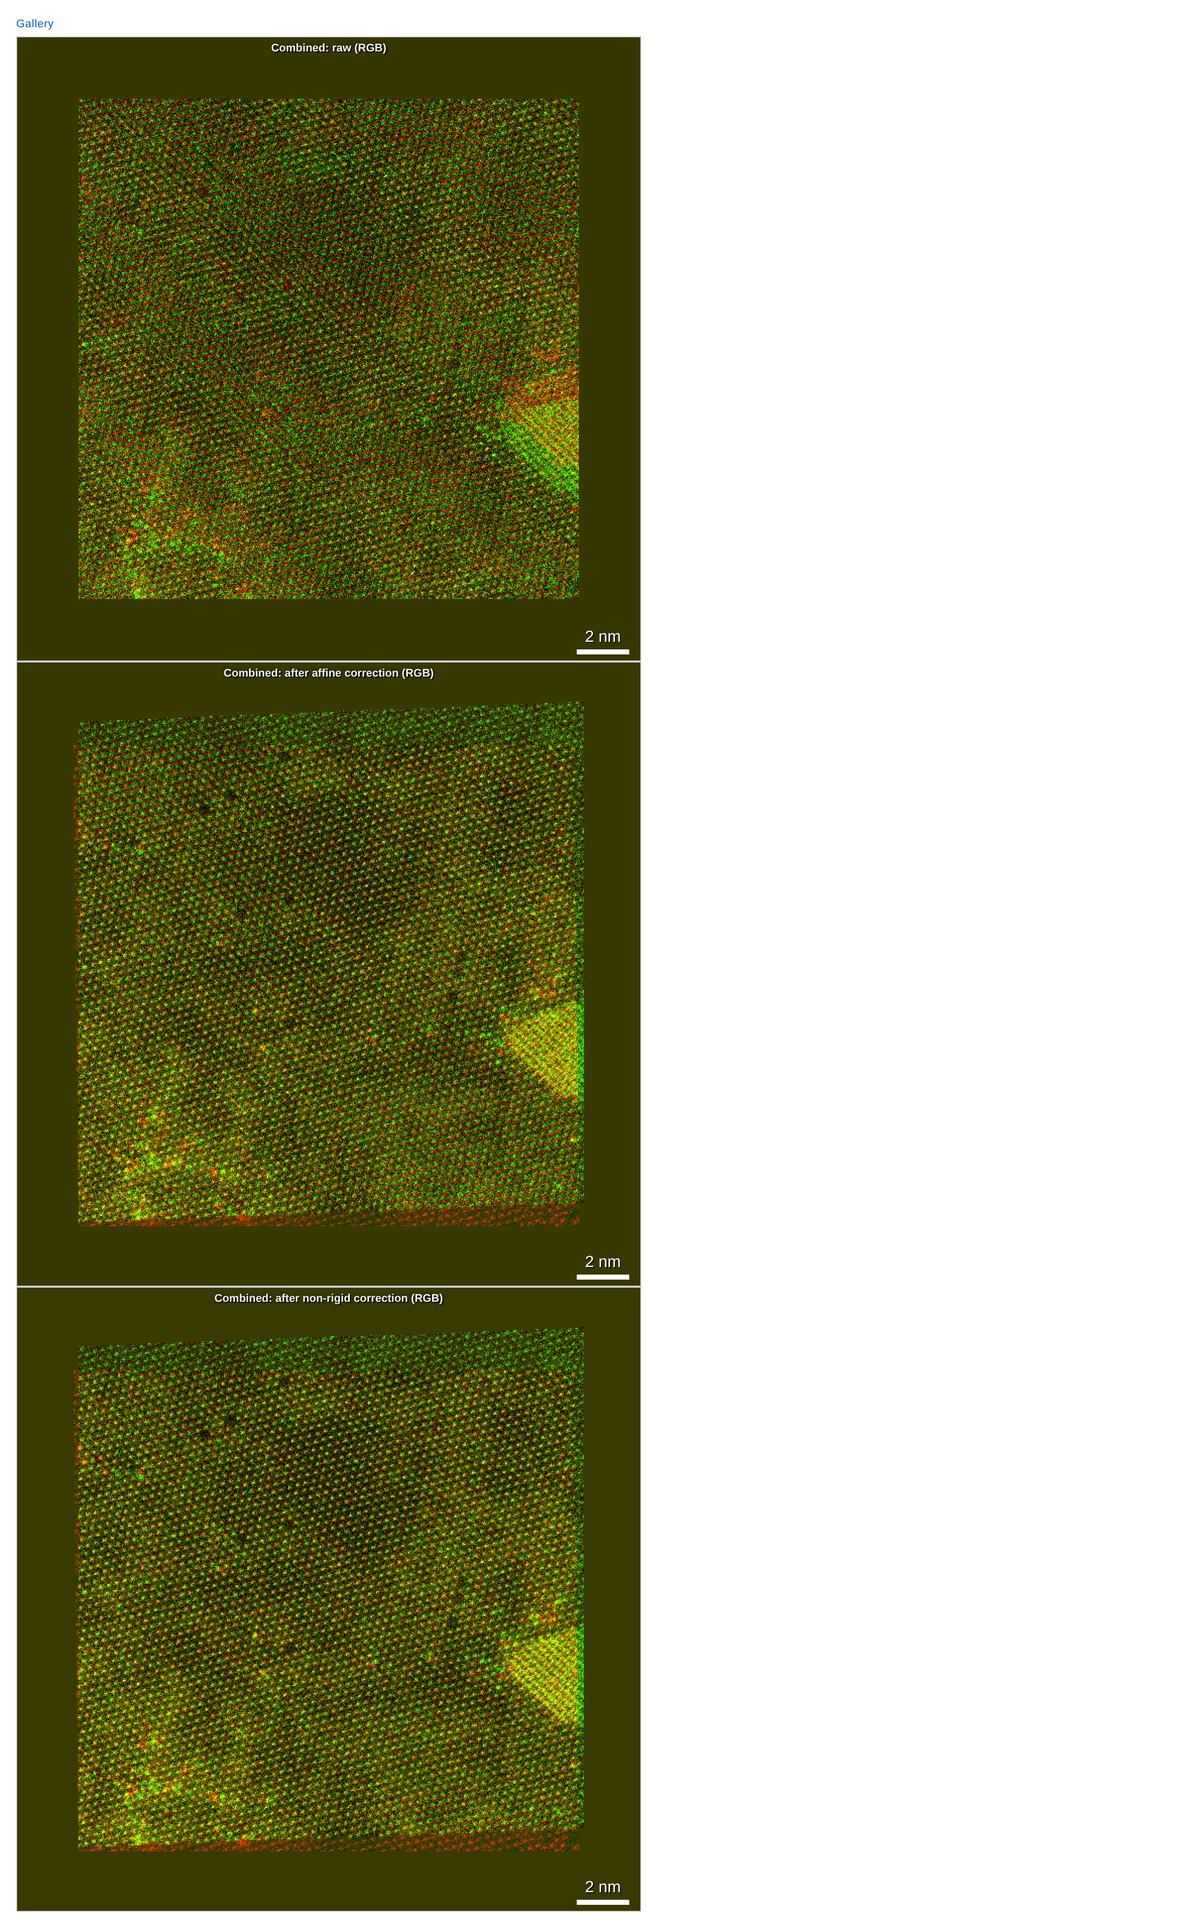

In [7]:
drift.plot_combined(
    stage=("initial", "affine", "nonrigid"),
    interactive=INTERACTIVE,
    width=620,
)


## Quantitative check


In [8]:
drift.report()


,Common NCC,Top third,Middle third,Bottom third,Coverage
Mutual stage,,,,,
before,0.066214,0.021732,0.068718,0.073990,0.928106
affine,0.248272,0.219939,0.276251,0.213982,0.928106
nonrigid,0.368006,0.348829,0.383370,0.341933,0.928106


## Inspect the corrected result

Inspect defects and edges, not only the repeating lattice. The linked
interactive panels make local zoom, pan, and contrast comparison available
without changing the correction.


  Display bin 3×: 2560×2560 → 853×853 (16 MB preview; full-res detail streams on zoom)


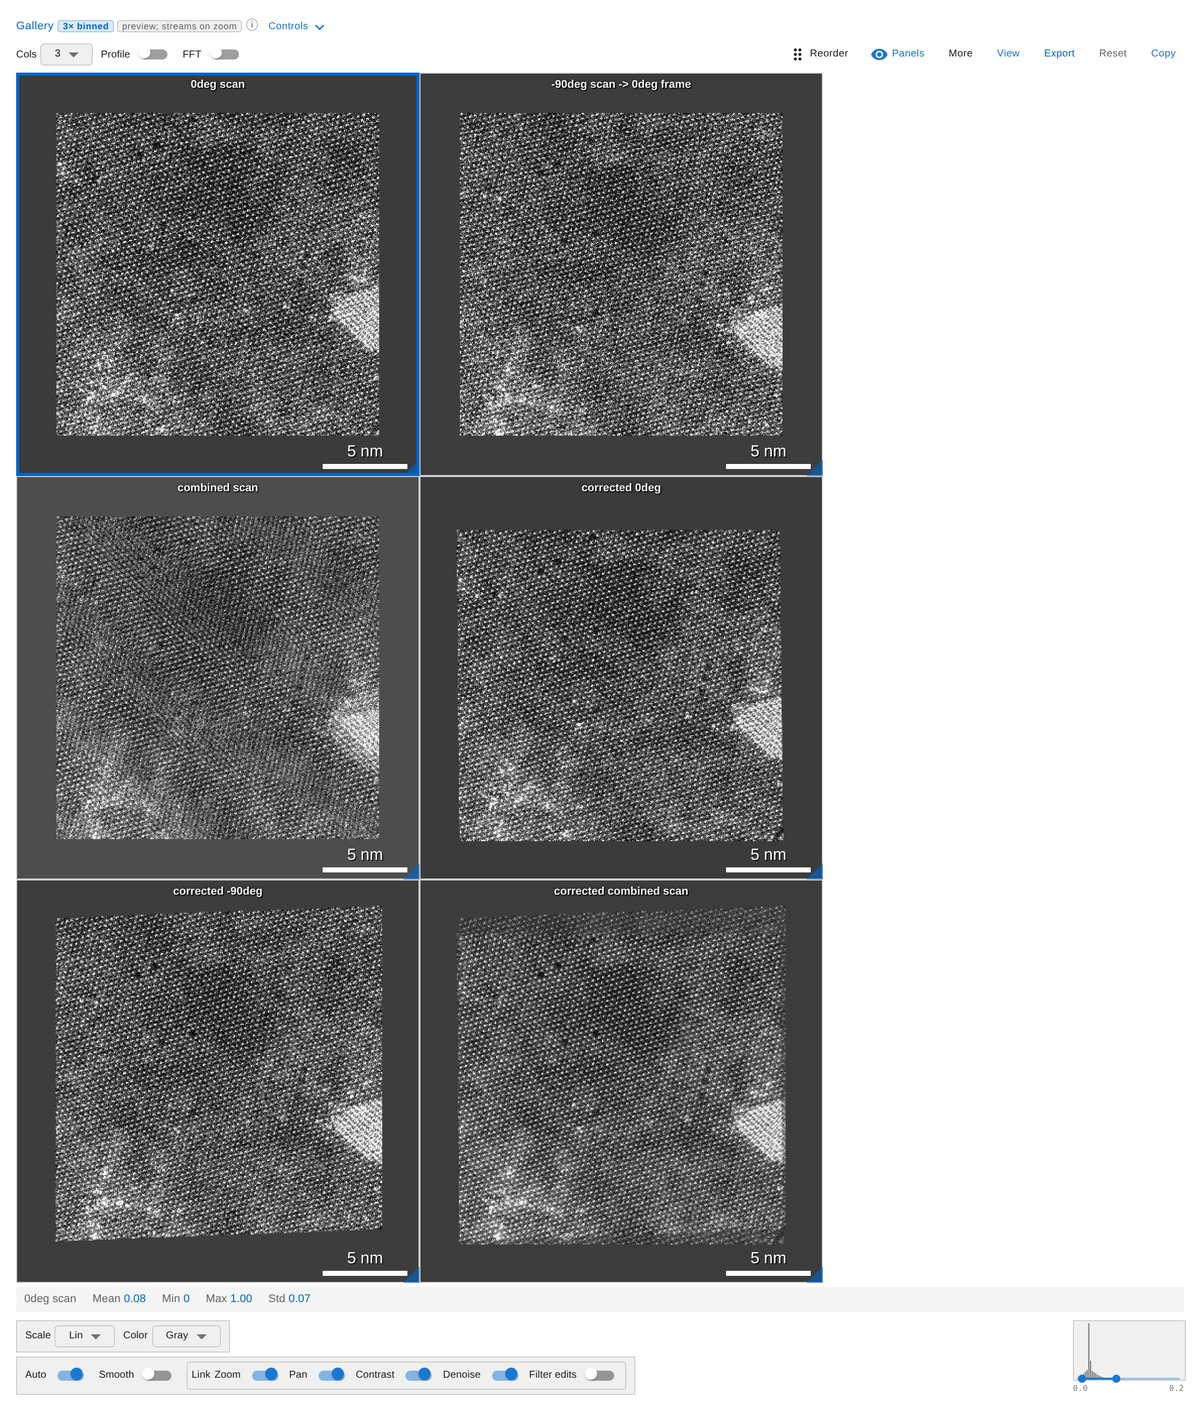

In [9]:
drift.show(
    mode=VIEW_MODE,
    cmap="gray",
    auto_contrast=True,
    link_contrast=True,
    smooth=False,
    show_fft=False,
)


## Takeaway

Non-rigid model selection is not “highest NCC wins.” First verify that the
motion bound permits improvement over affine. Then compare candidates from the
same affine checkpoint and accept extra knots only when the specimen visibly
requires within-scanline bending.

Regenerate this notebook with:

```bash
python tutorials/template/build_2d_nonrigid_safety_ws2_tutorial.py
```
